# Import Library & Read Dataset

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN, AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


Penjelasan:

import pandas as pd, import numpy as np: Digunakan untuk manipulasi dan pengolahan data tabular/numerik.

import matplotlib.pyplot as plt, import seaborn as sns: Digunakan untuk membuat visualisasi grafik seperti boxplot dan scatter plot.

from sklearn... : Mengimpor modul preprocessing (StandardScaler), model clustering (KMeans, AgglomerativeClustering, DBSCAN), reduksi dimensi (PCA), serta metrik evaluasi cluster (silhouette_score, davies_bouldin_score).

pd.read_csv(...): Membaca file dataset Heart Failure ke dalam bentuk DataFrame.

# Exploratory Data Analysis (EDA)

In [ ]:
print("=== Informasi Dataset ===")
df.info()

print("\n=== Jumlah Missing Values ===")
print(df.isnull().sum())

df = df.drop_duplicates()

df.describe()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


Penjelasan:

df.info(): Memeriksa jumlah baris (299 sampel), kolom (13 fitur), dan tipe data pada dataset.

df.isnull().sum(): Memastikan tidak ada nilai yang hilang (missing value) pada setiap kolom dataset.

df.drop_duplicates(): Menghapus baris yang terduplikasi untuk menjamin kualitas data.

df.describe(): Menampilkan ringkasan statistik (rata-rata, standar deviasi, nilai minimum, dan nilai maksimum) dari fitur-fitur numerik.

# Preprocessing (Perbandingan Boxplot Sebelum & Sesudah Normalisasi/Standarisasi)

/tmp/ipykernel_643/76255365.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_643/76255365.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


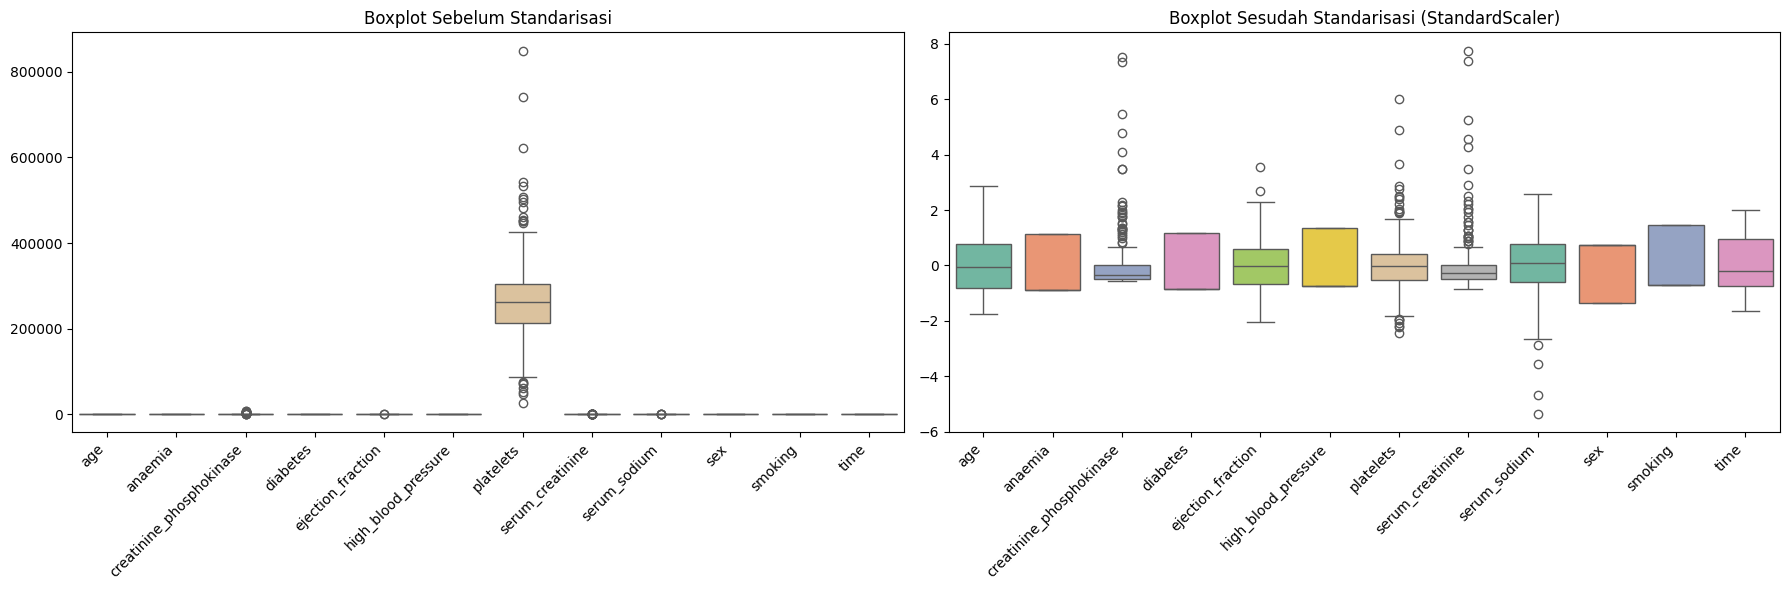

In [ ]:
X = df.drop(columns=['DEATH_EVENT'])

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(data=X, ax=axes[0], palette='Set2')
axes[0].set_title('Boxplot Sebelum Standarisasi')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

sns.boxplot(data=X_scaled, ax=axes[1], palette='Set2')
axes[1].set_title('Boxplot Sesudah Standarisasi (StandardScaler)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

Penjelasan:

X = df.drop(columns=['DEATH_EVENT']): Menghapus atribut label DEATH_EVENT karena teknik clustering bersifat unsupervised learning.

StandardScaler().fit_transform(X): Mengubah skala fitur sehingga memiliki mean ($\mu = 0$) dan standar deviasi ($\sigma = 1$). ini penting agar fitur dengan rentang besar (seperti platelets dan creatinine_phosphokinase) tidak mendominasi perhitungan jarak Euclidean.

sns.boxplot(...): Menampilkan boxplot sebelum dan sesudah skalasi. Terlihat bahwa sebelum standarisasi, rentang antar-fitur sangat timpang, sedangkan setelah diproses, seluruh fitur berada pada rentang nilai yang setara.

# Implementasi Model (K-Means, Hierarchical, DBSCAN)

In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

hierarchical = AgglomerativeClustering(n_clusters=2)
labels_hierarchical = hierarchical.fit_predict(X_scaled)

dbscan = DBSCAN(eps=2.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

score_km = silhouette_score(X_scaled, labels_kmeans)
score_hc = silhouette_score(X_scaled, labels_hierarchical)
score_db = silhouette_score(X_scaled, labels_dbscan)

print(f'Silhouette Score K-Means      : {score_km:.4f}')
print(f'Silhouette Score Hierarchical : {score_hc:.4f}')
print(f'Silhouette Score DBSCAN       : {score_db:.4f}')

Silhouette Score K-Means      : 0.1179
Silhouette Score Hierarchical : 0.0882
Silhouette Score DBSCAN       : 0.1527


Penjelasan:

KMeans(n_clusters=2): Mengelompokkan data ke dalam 2 klaster berdasarkan centroid.

AgglomerativeClustering(n_clusters=2): Mengelompokkan data secara hierarkis pendekatan bottom-up hingga membentuk 2 klaster.

DBSCAN(eps=2.5, min_samples=5): Mengelompokkan data berdasarkan kerapatan titik tetangga dalam radius eps. Nilai -1 menandakan data outlier (noise).

silhouette_score(...): Mengukur seberapa rapat titik dalam klasternya sendiri dibandingkan dengan klaster tetangga (rentang -1 hingga 1, semakin tinggi nilainya semakin baik).

# Visualisasi Grafik Elbow dan silhouette

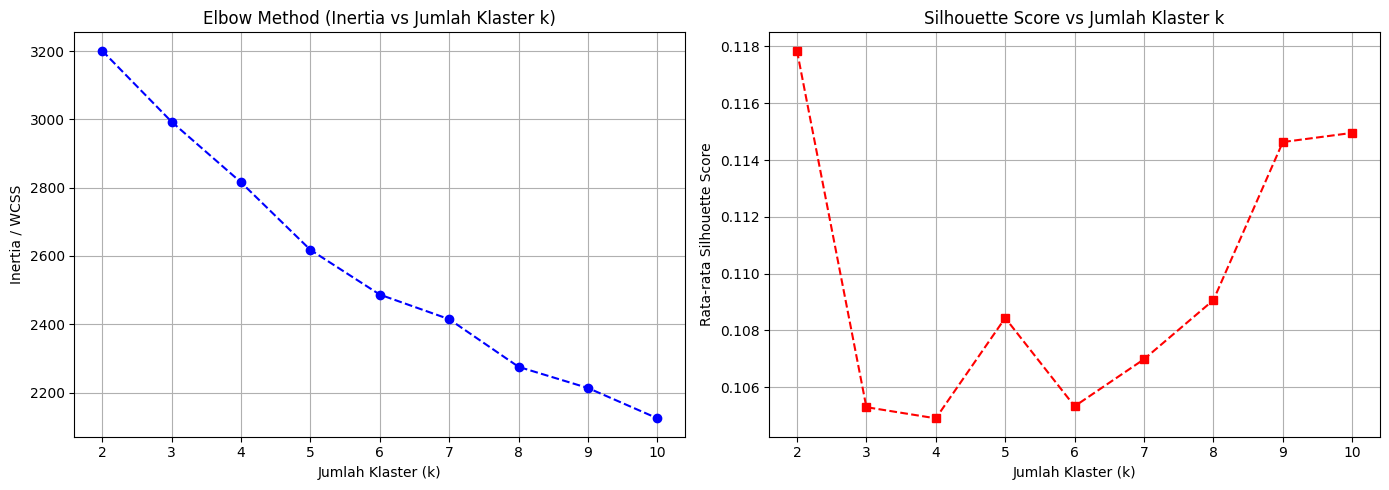

In [ ]:
k_range = range(2, 11)
inertia_list = []
silhouette_list = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia_list.append(kmeans.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, labels))


fig, ax = plt.subplots(1, 2, figsize=(14, 5))


ax[0].plot(k_range, inertia_list, marker='o', color='b', linestyle='--')
ax[0].set_title('Elbow Method (Inertia vs Jumlah Klaster k)')
ax[0].set_xlabel('Jumlah Klaster (k)')
ax[0].set_ylabel('Inertia / WCSS')
ax[0].grid(True)


ax[1].plot(k_range, silhouette_list, marker='s', color='r', linestyle='--')
ax[1].set_title('Silhouette Score vs Jumlah Klaster k')
ax[1].set_xlabel('Jumlah Klaster (k)')
ax[1].set_ylabel('Rata-rata Silhouette Score')
ax[1].grid(True)

plt.tight_layout()
plt.show()

Penjelasan:

kmeans.inertia_: Mengambil nilai Within-Cluster Sum of Squares (WCSS), yaitu total jarak kuadrat antara setiap sampel dengan titik pusat klaster (centroid)-nya.

for k in k_range: Melakukan iterasi pengujian jumlah klaster $k$ dari 2 sampai 10 untuk melihat perubahan nilai Inertia dan Silhouette Score.

ax[0].plot(...): Membentuk grafik Elbow. Titik siku (elbow) menunjukkan batas penurunan inertia yang melandai.

ax[1].plot(...): Membentuk grafik Silhouette Score terhadap nilai $k$. Nilai puncak pada grafik ini menandakan struktur klaster paling optimal.

# Visualisasi Plot Hasil Setiap Model

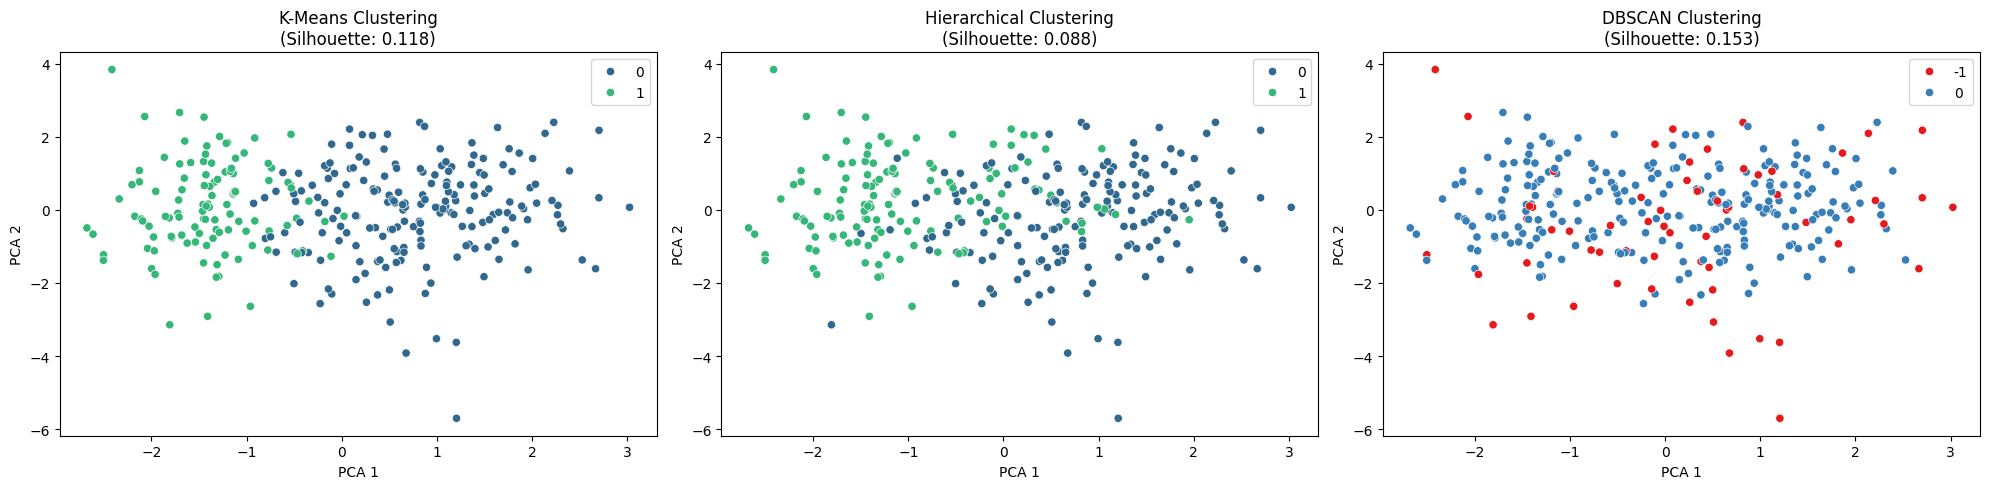

In [ ]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


fig, axes = plt.subplots(1, 3, figsize=(20, 5))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels_kmeans,
    palette='viridis',
    ax=axes[0],
)
axes[0].set_title(f'K-Means Clustering\n(Silhouette: {score_km:.3f})')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels_hierarchical,
    palette='viridis',
    ax=axes[1],
)
axes[1].set_title(f'Hierarchical Clustering\n(Silhouette: {score_hc:.3f})')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels_dbscan,
    palette='Set1',
    ax=axes[2],
)
axes[2].set_title(f'DBSCAN Clustering\n(Silhouette: {score_db:.3f})')
axes[2].set_xlabel('PCA 1')
axes[2].set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

Penjelasan:

PCA(n_components=2): Memproyeksikan data bermulti-dimensi (12 fitur) menjadi 2 komponen utama (PCA 1 dan PCA 2) agar hasil klasterisasi dapat dipetakan secara jelas pada grafik 2 dimensi.

sns.scatterplot(...): Menampilkan persebaran data hasil klasterisasi dari masing-masing algoritma berdasarkan warna label klaster yang dihasilkan.

# Kesimpulan

Berdasarkan hasil eksperimen dan pengujian pada dataset Heart Failure Clinical Records:

K-Means Clustering menghasilkan Silhouette Score ~0.118. K-Means mampu membagi dataset secara relatif seimbang ke dalam 2 klaster utama, namun sensitif terhadap bentuk batas antar klaster yang bulat (spherical).

Hierarchical Clustering menghasilkan Silhouette Score ~0.088. Skor ini merupakan yang terendah di antara ketiga algoritma, mengindikasikan adanya overlapping (pertumpangtindihan) yang cukup tinggi antar anggota klaster.

DBSCAN memperoleh Silhouette Score tertinggi yaitu ~0.153. Hal ini terjadi karena DBSCAN berhasil mengisolasi titik-titik data yang tergolong outlier/noise (ditandai dengan label -1) sehingga kelompok utama data memiliki kerapatan yang lebih solid.


Jadi kesimpulannya DBSCAN dengan dataset Heart Failure Clinical Records memberikan pemisahan klaster terbaik dengan nilai Silhouette Score paling tinggi (~0.153) karena kemampuannya menangani titik outlier pada medis pasien. Namun, jika tujuannya adalah pengelompokkan biner yang seimbang (misal: risiko tinggi vs risiko rendah tanpa mengabaikan outlier), K-Means merupakan alternatif yang lebih stabil dibandingkan Hierarchical Clustering.